# Deep Learning: More Convolutional Neural Networks

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from tqdm import tqdm

print(f"Pytorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")

Pytorch version: 2.9.1
Torchvision version: 0.24.1



### Note: Python must be 3.11.x

If your kernel shows a value > 3.11.x you will need to downgrade. Please email the staff for help

In [2]:
# DEVICE CONFIGURATION
if torch.backends.mps.is_available():          # Apple Silicon
    device = torch.device("mps")
elif torch.cuda.is_available():                # CUDA GPU
    device = torch.device("cuda")
else:
    device = torch.device("cpu")               # Fallback

print("Using device:", device)

Using device: mps


For today's small group, we will walk through the process of setting up a convolutional neural network ("CNN" for short) using the `pytorch` package!

Recall from lecture that CNNs are generally used to process gridded data or images.

Let's begin by loading one of the toy datasets included in `pytorch`:

In [3]:
# init preprocessing for CIFAR-10 dataset (images are 32x32x3)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))  # normalize to [-1, 1]
])

In [4]:
batch_size = 100
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                             download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                            download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Great! We have image data now. But what does it look like?

Let's plot the different classes below using `matplotlib`

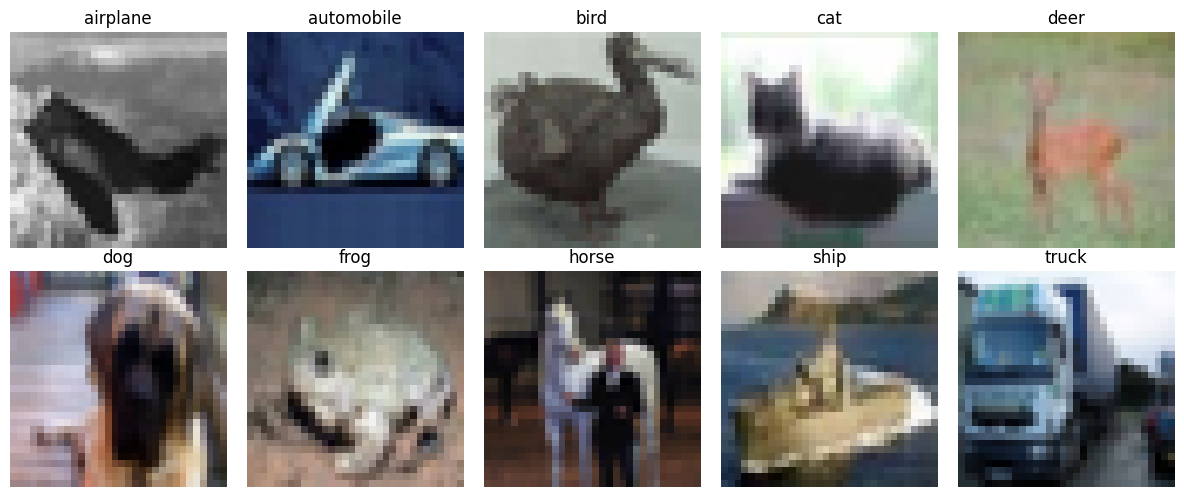

In [7]:
# Plot each class here
# Plot each class here
import matplotlib.pyplot as plt
import numpy as np

# CIFAR-10 class names
classes = train_dataset.classes  # ['airplane', 'automobile', ..., 'truck']

# Helper to un-normalize and show an image
def imshow(img, ax):
    # img is a 3×H×W tensor normalized to [-1, 1]
    img = img * 0.5 + 0.5            # unnormalize back to [0, 1]
    npimg = img.numpy()
    npimg = np.transpose(npimg, (1, 2, 0))  # C×H×W -> H×W×C
    ax.imshow(npimg)
    ax.axis('off')

# Collect one example image for each class
examples = {}
for images, labels in train_loader:
    for img, label in zip(images, labels):
        label_idx = label.item()
        if label_idx not in examples:
            examples[label_idx] = img
        if len(examples) == len(classes):
            break
    if len(examples) == len(classes):
        break

# Plot them in a grid (2 rows × 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()

for idx, class_name in enumerate(classes):
    ax = axes[idx]
    imshow(examples[idx], ax)
    ax.set_title(class_name)

plt.tight_layout()
plt.show()

## Building a CNN

Staff:
- Reference lecture: CNNs involve stacking multiple **layers**
- The first part of a CNN involves stacking multiple layers of convolutional, activation, and maxpool layers 
- The example code below shows 3 of these stacks of layers!
<p align="left">
    <img src = "https://media.geeksforgeeks.org/wp-content/uploads/20250529121802516451/Convolutional-Neural-Network-in-Machine-Learning.webp" width = "500">
</p>

### Activation Functions

Staff:
- Please briefly review some of the common activation functions (there will be a table on this at the beginning of lecture)
- Discuss 3 of the most common activation functions
- Be sure to define what their names are in tensorflow

Please add comments to this code:

In [8]:
# Define a simple CNN
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.layer3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )
        self.fc = nn.Linear(128*4*4, 10)  # CIFAR-10 has 10 classes

    def forward(self, x):
        out = self.layer1(x)
        out = self.layer2(out)
        out = self.layer3(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

model = CNN().to(device)

### Q: What do you think will happen to your CNN as you change the activation function?
Feel free to try this by changing `activation_func`!

### A: 
YOUR ANSWER HERE

----
## Training a CNN
Staff:
- Please discuss the selection process for optimizer and loss inputs
- Define what learning rate is
- Give an overview of 2-3 common loss functions and their behavior

[This](https://www.geeksforgeeks.org/machine-learning/epoch-in-machine-learning/) reference will be useful

In [8]:
#  Loss and optimizer
learning_rate = 0.001
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

### Q: What might happen if we changed our loss from __ to __ ?

### A:
YOUR ANSWER HERE

### Q: What happens if the `learning_rate` parameter is too high? Or too low?

### A:
YOUR ANSWER HERE

In [9]:
# Training loop
# STAFF: Please add check for early stopping!!!
num_epochs = 10
for epoch in range(num_epochs):
    print(f"Epoch {epoch+1}/{num_epochs}")
    model.train()
    running_loss = 0.0
    for i,(images, labels) in enumerate(tqdm(train_loader)):
        images = images.to(device)
        labels = labels.to(device)
        
        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()

    print(f'Loss: {loss.item():.4f} \n')

Epoch 1/10


100%|██████████| 500/500 [00:33<00:00, 14.74it/s]


Loss: 1.1074 

Epoch 2/10


100%|██████████| 500/500 [00:20<00:00, 24.03it/s]


Loss: 0.6503 

Epoch 3/10


...

Loss: 0.2910 

Epoch 9/10


100%|██████████| 500/500 [00:47<00:00, 10.44it/s]


Loss: 0.2538 

Epoch 10/10


100%|██████████| 500/500 [00:35<00:00, 14.04it/s]

Loss: 0.3827 



### Q: What happens if you increase `epochs`? Will performance always improve as `epochs` increases?

### A:
YOUR ANSWER HERE

----
## Validating a CNN

Staff: Please add comments/explanations as needed to this code!

In [10]:
# Testing
model.eval()
with torch.no_grad():
    correct = 0
    total = 0
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f'Test Accuracy: {100 * correct / total:.2f}%')


Test Accuracy: 75.79%


----

## Analyzing Performance
- Staff: prompt some reflection about the plot below

In [11]:
# Plot accuracy vs. epochs